# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name: Dynamic  
Created by Scott Du (016955484), Sanjitha Kurra (017182958), Dalen Martin ()  
Last updated: March 18, 2026  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

ddos = pd.read_csv('/content/drive/Shareddrives/CS133 Project/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
ddos.columns = ddos.columns.str.strip()
ddos.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

In [ ]:
ddos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 85 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow ID                      225745 non-null  object 
 1   Source IP                    225745 non-null  object 
 2   Source Port                  225745 non-null  int64  
 3   Destination IP               225745 non-null  object 
 4   Destination Port             225745 non-null  int64  
 5   Protocol                     225745 non-null  int64  
 6   Timestamp                    225745 non-null  object 
 7   Flow Duration                225745 non-null  int64  
 8   Total Fwd Packets            225745 non-null  int64  
 9   Total Backward Packets       225745 non-null  int64  
 10  Total Length of Fwd Packets  225745 non-null  int64  
 11  Total Length of Bwd Packets  225745 non-null  int64  
 12  Fwd Packet Length Max        225745 non-null  int64  
 13 

In [ ]:
with pd.option_context('display.max_columns', None):
  print(ddos.describe())

         Source Port  Destination Port       Protocol  Flow Duration  \
count  225745.000000      225745.00000  225745.000000   2.257450e+05   
mean    38257.568402        8879.61946       7.600288   1.624165e+07   
std     23057.302075       19754.64740       3.881586   3.152437e+07   
min         0.000000           0.00000       0.000000  -1.000000e+00   
25%     18990.000000          80.00000       6.000000   7.118000e+04   
50%     49799.000000          80.00000       6.000000   1.452333e+06   
75%     58296.000000          80.00000       6.000000   8.805237e+06   
max     65534.000000       65532.00000      17.000000   1.199999e+08   

       Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  \
count      225745.000000           225745.000000                225745.000000   
mean            4.874916                4.572775                   939.463346   
std            15.422874               21.755356                  3249.403484   
min             1.000000   

### Answer
One formatting concern that we have is the lack of unique values in some categories. For example, "Bwd Packet Length Min", where most of the data is 0, while the max is in the thousands.  

Another concern is inconclusive data. Some columns have infinity as their value, such as "Flow Packets/s". This data may or may not benefit our analysis of network traffic. If it is clear that it does not help, we will drop the data entries that have any infinity or NaN values.  

The last concern we have is that some columns only have one value to them, which is 0. Between benign and malicious, some categories, such as "Bwd PSH Flags", are all the same. These columns can clutter our data and learning, so we can drop these columns.

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

Most of our data is primarily numerical. Our only categorical columns are the Flow ID, Source IP, Destination IP, Timestamp, and Label. The Flow ID is an index column and cannot be used in data analysis. The Timestamp is an arbitrary date and time so it cannot be used in data analysis as well. This leaves only 3 categorical columns. One numerical column, Protocol, can be converted into a categorical one to say the actual protocol name and to give us another categorical column to analyze.

In [ ]:
if ddos['Protocol'].dtype != 'object':
  protocol_dict = {'0':'HOPOPT', '6':'TCP', '17':'UDP'}

  ddos['Protocol'] = ddos['Protocol'].astype(str)
  ddos['Protocol'] = ddos['Protocol'].map(protocol_dict)
ddos.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,TCP,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,TCP,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,TCP,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,TCP,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,TCP,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Question: Which protocols do attacks primarily use, compared to benign flows?

Text(0.5, 1.0, 'Protocols used by attacks compared to benign flows')

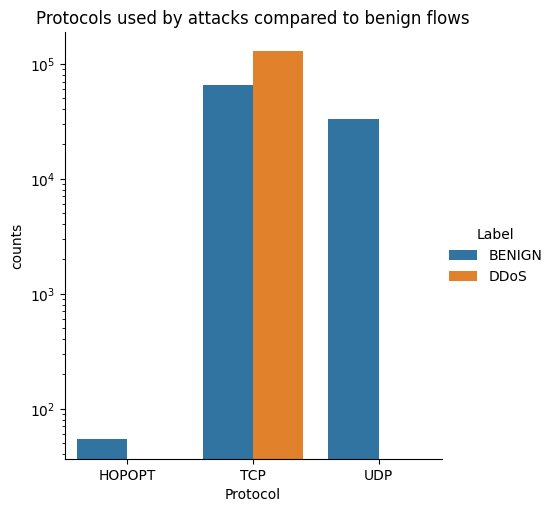

In [ ]:
counts = ddos.groupby(['Protocol', 'Label']).size().reset_index(name='counts')

sns.catplot(data=counts,
            x='Protocol',
            y='counts',
            hue='Label',
            kind='bar')

plt.yscale('log')
plt.title('Protocols used by attacks compared to benign flows')

### Answer
The protocol used by DDoS attacks is TCP, while the benign traffic use a variety of protocols. The most used protocol for benign traffic is TCP.

### Q3: Come up with a another unique question. This question must use map() or apply()

### Question: How distributed are attacks coming from internal and external IPs and are they targeting web services, system ports, or random ports?

In [ ]:
print(ddos['Source IP'].unique())
print(ddos['Destination IP'].unique())
print(ddos['Source Port'].unique())
print(ddos['Destination Port'].unique())

['104.16.207.165' '104.16.28.216' '104.17.241.25' ... '52.84.145.166'
 '52.84.145.38' '8.41.222.187']
['192.168.10.5' '192.168.10.16' '192.168.10.8' ... '52.84.145.230'
 '23.21.84.138' '192.229.173.28']
[  443    80 27328 ...  8796  6547 48588]
[54865 55054 55055 ... 39950 61301 61326]


In [ ]:
'''
The Internet Assigned Numbers Authority (IANA) has reserved the following three blocks of the IP address space for private internets:

10.0.0.0 - 10.255.255.255 (10/8 prefix)
172.16.0.0 - 172.31.255.255 (172.16/12 prefix)
192.168.0.0 - 192.168.255.255 (192.168/16 prefix)
'''
def ip_type(ip):
  ip_split = ip.split('.')
  if ip[0] == '10':
    return 'Internal'
  elif ip_split[0] == '172' and int(ip_split[1]) >= 16 and int(ip_split[1]) <= 31:
    return 'Internal'
  elif ip_split[0] == '192' and ip_split[1] == '168':
    return 'Internal'
  else:
    return 'External'

'''
Key Web Ports
Port 80 (HTTP): Medium Standard, unsecured web traffic.
Port 443 (HTTPS): DPS Telecom Secure web traffic using SSL/TLS encryption.
Ports 0–1023 (System/Well-Known Ports): Reserved for system services and privileged applications.
Ports 1024–49151 (Registered Ports): Assigned by IANA for specific, commonly used applications.
Ports 49152–65535 (Dynamic/Ephemeral Ports): Used temporarily by applications for client-side communication.
'''
def port_category(port):
    if port in [80, 443]:
        return 'Web'
    elif port < 1024:
        return 'System'
    else:
        return 'Ephemeral'


ddos['Source IP Type'] = ddos['Source IP'].apply(ip_type)
ddos['Destination IP Type'] = ddos['Destination IP'].apply(ip_type)

ddos['Source Port Category'] = ddos['Source Port'].apply(port_category)
ddos['Destination Port Category'] = ddos['Destination Port'].apply(port_category)

ddos

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Source IP Type,Destination IP Type,Source Port Category,Destination Port Category
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,TCP,7/7/2017 3:30,3,2,0,...,0,0.0,0.0,0,0,BENIGN,External,Internal,Web,Ephemeral
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,TCP,7/7/2017 3:30,109,1,1,...,0,0.0,0.0,0,0,BENIGN,External,Internal,Web,Ephemeral
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,TCP,7/7/2017 3:30,52,1,1,...,0,0.0,0.0,0,0,BENIGN,External,Internal,Web,Ephemeral
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,TCP,7/7/2017 3:30,34,1,1,...,0,0.0,0.0,0,0,BENIGN,External,Internal,Web,Ephemeral
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,TCP,7/7/2017 3:30,3,2,0,...,0,0.0,0.0,0,0,BENIGN,External,Internal,Web,Ephemeral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225740,192.168.10.15-72.21.91.29-61374-80-6,72.21.91.29,80,192.168.10.15,61374,TCP,7/7/2017 5:02,61,1,1,...,0,0.0,0.0,0,0,BENIGN,External,Internal,Web,Ephemeral
225741,192.168.10.15-72.21.91.29-61378-80-6,72.21.91.29,80,192.168.10.15,61378,TCP,7/7/2017 5:02,72,1,1,...,0,0.0,0.0,0,0,BENIGN,External,Internal,Web,Ephemeral
225742,192.168.10.15-72.21.91.29-61375-80-6,72.21.91.29,80,192.168.10.15,61375,TCP,7/7/2017 5:02,75,1,1,...,0,0.0,0.0,0,0,BENIGN,External,Internal,Web,Ephemeral
225743,192.168.10.15-8.41.222.187-61323-80-6,8.41.222.187,80,192.168.10.15,61323,TCP,7/7/2017 5:02,48,2,0,...,0,0.0,0.0,0,0,BENIGN,External,Internal,Web,Ephemeral


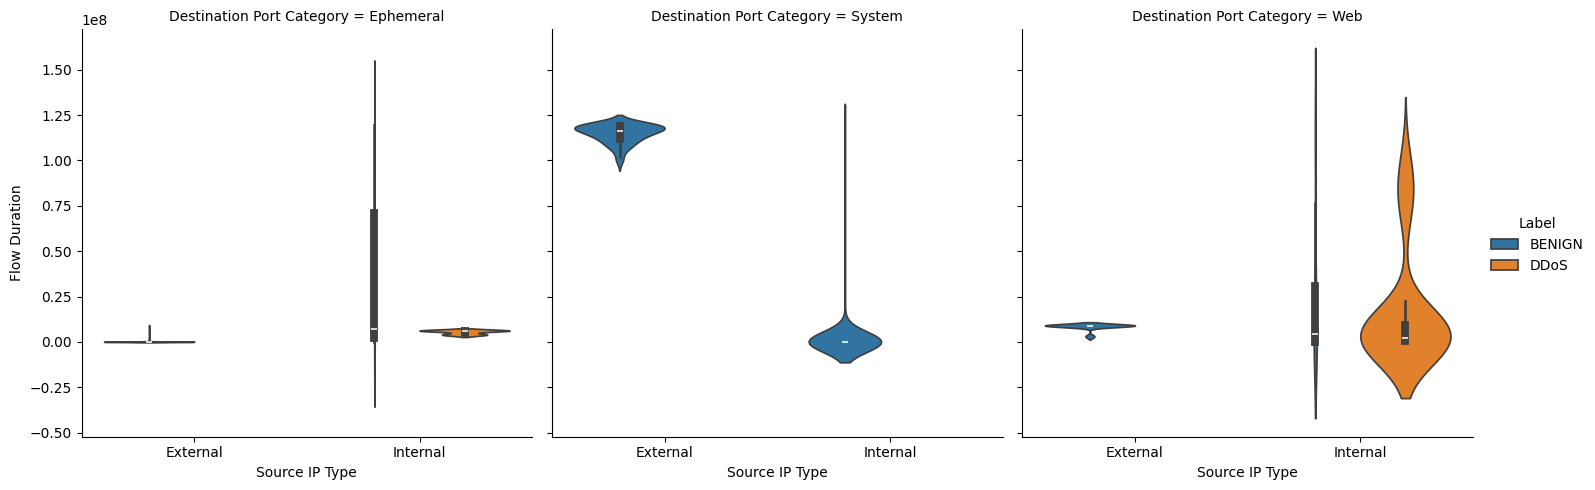

In [ ]:
sns.catplot(data=ddos,
            x='Source IP Type',
            y='Flow Duration',
            hue='Label',
            kind='violin',
            bw_method=0.5,
            col='Destination Port Category',
            )

### Answer
It seems like all DDoS attacks have come from internal source IPs, specifically targeting web services and random ports. For DDoS attacks, the flow duration of the attacks is usually shorter compared to benign network traffic.

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [ ]:
# TODO: Update after learning about interactive plots (Currently omitted from submission)

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

### Answer
We have not found another complementary dataset yet, but a dataset that has more variation of DDoS attacks using different conditions, such as more external or internal IPs, would strengthen and balance our current data.  

The pseudocode of combining datasets and reshaping data is below:

In [ ]:
# new_dataset = pd.read_csv(new_data_file)

# # Something similar depending on data of the new dataset.
# ddos.merge(new_dataset, how='left', on='Source IP')

# # Reshaping data by converting values, binning, and/or aggregating
# ddos['Protocol'] = ddos['Protocol'].astype(str)
# ddos['Protocol'] = ddos['Protocol'].map(protocol_dict)

# ddos['Flow_Category'] = bin_flow_duration(ddos['Flow Duration'])

# pivot_table = pd.pivot_table(ddos, protocol, flow duration, take mean)